In [ ]:
# Thomas J. Sargent and John Stachurski 사이트 
# https://python.quantecon.org/intro.html
# topic 135. Linear Regression in Python

#!pip install linearmodels  # 코랩일 경우. 로컬에서는 터미널에서 실행.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from linearmodels.iv import IV2SLS
import seaborn as sns
sns.set_theme()


In [6]:
#df1 = pd.read_stata('https://github.com/QuantEcon/data-lectures/raw/main/lectures/maketable1.dta')
url1 = 'https://github.com/QuantEcon/data-lectures/raw/main/lectures/maketable1.dta'
df1 = pd.read_stata(url1)
df1.info()
df1.head()                 # Show first 5 rows. df1.tail()  last 5 rows.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   shortnam  163 non-null    object 
 1   euro1900  154 non-null    float32
 2   excolony  162 non-null    float32
 3   avexpr    121 non-null    float32
 4   logpgp95  148 non-null    float32
 5   cons1     88 non-null     float32
 6   cons90    88 non-null     float32
 7   democ00a  87 non-null     float32
 8   cons00a   91 non-null     float32
 9   extmort4  87 non-null     float32
 10  logem4    87 non-null     float32
 11  loghjypl  123 non-null    float32
 12  baseco    64 non-null     float32
dtypes: float32(12), object(1)
memory usage: 9.0+ KB


,shortnam,euro1900,excolony,avexpr,logpgp95,cons1,cons90,democ00a,cons00a,extmort4,logem4,loghjypl,baseco
0,AFG,0.000000,1.0,NaN,NaN,1.0,2.0,1.0,1.0,93.699997,4.540098,NaN,NaN
1,AGO,8.000000,1.0,5.363636,7.770645,3.0,3.0,0.0,1.0,280.000000,5.634789,-3.411248,1.0
2,ARE,0.000000,1.0,7.181818,9.804219,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ARG,60.000004,1.0,6.386364,9.133459,1.0,6.0,3.0,3.0,68.900002,4.232656,-0.872274,1.0
4,ARM,0.000000,0.0,NaN,7.682482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


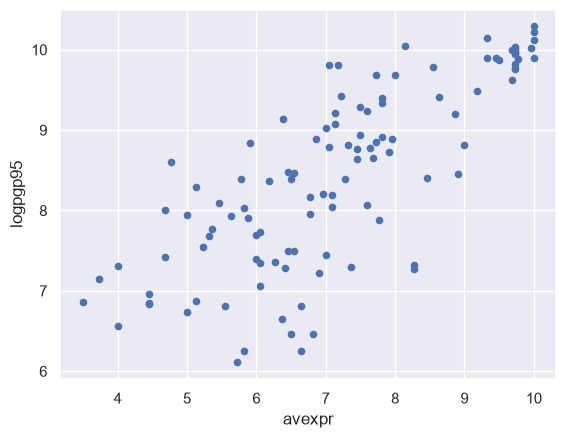

In [3]:
df1.plot(x='avexpr', y='logpgp95', kind='scatter')  # avexpr = index. protection against expropriation 
plt.show()

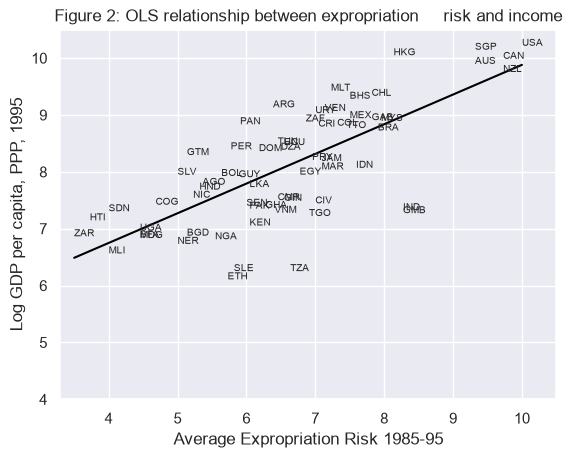

In [16]:
# fit simple linear model and display 

# Dropping NA's is required to use numpy's polyfit
df1_subset = df1.dropna(subset=['logpgp95', 'avexpr'])

# Use only 'base sample' for plotting purposes
df1_subset = df1_subset[df1_subset['baseco'] == 1]

X = df1_subset['avexpr']
y = df1_subset['logpgp95']
labels = df1_subset['shortnam']

# Replace markers with country labels
fig, ax = plt.subplots()
ax.scatter(X, y, marker='')                      # 점, 이런 것 대신 '' 빈 것. 공. 여기에다 단축 이름을 쓴다는 것이군.

for i, label in enumerate(labels):
    ax.annotate(label, (X.iloc[i], y.iloc[i]), fontsize='xx-small' ) # =6) 
                                                 # (x,y) 쌍에 레이블 붙인다. 'x-small' 'small' 등

# Fit a linear trend line                        # 여기에 회귀선을 추가한다는 것. 코딩 기술 들어가는군.
ax.plot(np.unique(X),
         np.poly1d(np.polyfit(X, y, 1))(np.unique(X)),
         color='black')
#  np.unique(X). X 값들의 중복을 제거하고 정렬
#  np.polyfit(X, y, 1). X와 y 사이의 1차 직선의 방정식의 계수 $a$(기울기)와 $b$(Y절편)를 추정. 
#            반환값: [기울기 a, 절편 b] 형태의 리스트
#  np.poly1d(...) 계수([a, b])를 입력받아 진짜 함수($f(x) = ax + b$) 형태로 완성, 이것은 함수. 
#            뒤에 (X값)을 붙이면 곧바로 Y 예상값이 계산. 
#  결국 위 식은 plot( x값, y예상치, 검은색). scatter로 하면 점을 찍는데, plot은 선이라 기술을 썼군. 

ax.set_xlim([3.3,10.5])
ax.set_ylim([4,10.5])
ax.set_xlabel('Average Expropriation Risk 1985-95')
ax.set_ylabel('Log GDP per capita, PPP, 1995')
ax.set_title('Figure 2: OLS relationship between expropriation \
    risk and income')
plt.show()

In [ ]:
# 그런데 여기서부터 데이터 셋이 바뀌었어. df1_subset --> df1으로 
df1['const'] = 1      # 간단하게 n by 1 시리즈 1이 입력되는 군...
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163 entries, 0 to 162
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   shortnam  163 non-null    object 
 1   euro1900  154 non-null    float32
 2   excolony  162 non-null    float32
 3   avexpr    121 non-null    float32
 4   logpgp95  148 non-null    float32
 5   cons1     88 non-null     float32
 6   cons90    88 non-null     float32
 7   democ00a  87 non-null     float32
 8   cons00a   91 non-null     float32
 9   extmort4  87 non-null     float32
 10  logem4    87 non-null     float32
 11  loghjypl  123 non-null    float32
 12  baseco    64 non-null     float32
 13  const     163 non-null    int64  
dtypes: float32(12), int64(1), object(1)
memory usage: 10.3+ KB


In [ ]:
reg1 = sm.OLS(endog=df1['logpgp95'], exog=df1[['const', 'avexpr']], missing='drop')
type(reg1)
# 이것은 모델 설정. 추정 단계는 아니로군. 추정하라는 명령 필요.
# 상수항 추가하는 옵션 쓰는 것보다 훨씬 이해가 됨.

statsmodels.regression.linear_model.OLS

In [ ]:
results = reg1.fit()
type(results)
# results에 모듈이 실행한 결과 집합.

statsmodels.regression.linear_model.RegressionResultsWrapper

In [21]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:               logpgp95   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     171.4
Date:                Sat, 15 Aug 2026   Prob (F-statistic):           4.16e-24
Time:                        12:24:38   Log-Likelihood:                -119.71
No. Observations:                 111   AIC:                             243.4
Df Residuals:                     109   BIC:                             248.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.6261      0.301     15.391      0.0

In [ ]:
mean_expr = np.mean(df1['avexpr'])
mean_expr
# 사이트에서는   np.mean(df1_subset['avexpr']) 이라 값이 약간 달라.
# 6.516 이후 다시 df1 사용. 약간 미스테이크.

np.float32(7.066491)

In [ ]:
predicted_logpdp95 = 4.63 + 0.53 * 7.07
predicted_logpdp95

8.37498

In [ ]:
results.predict(exog=[1, mean_expr])
# 위와 다른 것은, 위 셀에서는 라운딩 에라가 들어가니까. 

array([8.38455358])

In [ ]:
results.predict()             # 주어진 X에서 y 예측 값 전체.
#results.predict().shape       # 원소 111개 배열임. 즉, yhat



array([7.47885399, 8.44589264, 8.02281318, 9.58216343, 9.79974721,
       9.77557101, 6.99533453, 7.357974  , 9.36457965, 8.8810602 ,
       8.61512453, 7.62390967, 8.83270831, 8.73600426, 9.79974721,
       9.9448029 , 8.78435641, 8.76018046, 8.34918885, 8.05907723,
       7.11621427, 8.51842074, 8.3733648 , 9.34040345, 9.79974721,
       7.91402129, 8.08325318, 8.10742912, 8.22830911, 9.77557101,
       7.67226156, 9.79974721, 9.79974721, 8.78435641, 9.82392291,
       7.96237344, 8.10742912, 9.02611588, 8.78435641, 7.357974  ,
       7.75687751, 8.9535883 , 7.45467804, 6.60851899, 9.41293155,
       8.66347642, 9.02611588, 9.79974721, 7.16456642, 9.79974721,
       9.17117208, 9.65469102, 8.39754075, 8.22830911, 9.79974721,
       7.84149345, 9.21952397, 8.3733648 , 7.84149345, 9.9448029 ,
       8.39754075, 6.99533453, 8.61512453, 6.75357481, 8.47006859,
       8.54259668, 8.08325318, 8.25248506, 8.85688425, 7.28544615,
       7.57555778, 7.40632589, 9.9448029 , 9.9206267 , 9.79974

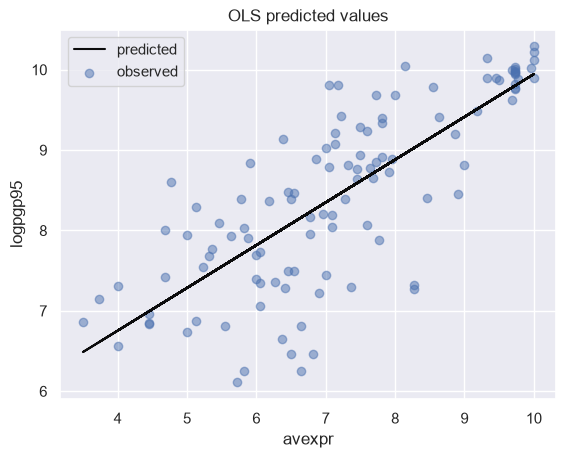

In [35]:
# 첫 그림 다시 그려보기. 실제 자료점과 예측 자료점.

# # Drop missing observations from whole sample

df1_plot = df1.dropna(subset=['logpgp95', 'avexpr'])

# Plot predicted values

fix, ax = plt.subplots()
#ax.scatter(df1_plot['avexpr'], results.predict(), alpha=0.5, label='predicted')
# 예측 점들을 선으로 이으려면, plot으로 합체.
ax.plot(df1_plot['avexpr'], results.predict(), alpha=0.95, label='predicted', color='black')
# Plot observed values

ax.scatter(df1_plot['avexpr'], df1_plot['logpgp95'], alpha=0.5,
        label='observed')

ax.legend()
ax.set_title('OLS predicted values')
ax.set_xlabel('avexpr')
ax.set_ylabel('logpgp95')
plt.show()        # 이 지점까지 생성된 그래프는 모두 한 화면에 출력 후 그래프 생성 종료.

In [44]:
# gdp에 영향을 주는 다른 요인도 고려
url2 = 'https://github.com/QuantEcon/data-lectures/raw/main/lectures/maketable2.dta'
df2 = pd.read_stata(url2)
# df2 = pd.read_stata('https://github.com/QuantEcon/data-lectures/raw/main/lectures/maketable2.dta')
#df2.info()
#df2.head()   # 이건 왜 안보일까?

# Add constant term to dataset
df2['const'] = 1

# Create lists of variables to be used in each regression
X1 = ['const', 'avexpr']
X2 = ['const', 'avexpr', 'lat_abst']
X3 = ['const', 'avexpr', 'lat_abst', 'asia', 'africa', 'other']

# Estimate an OLS regression for each set of variables
reg1 = sm.OLS(df2['logpgp95'], df2[X1], missing='drop').fit()
reg2 = sm.OLS(df2['logpgp95'], df2[X2], missing='drop').fit()
reg3 = sm.OLS(df2['logpgp95'], df2[X3], missing='drop').fit()
print(reg1)

In [42]:
# 결과, 3개 모델을 정리한다는 것. 

info_dict={'R-squared' : lambda x: f"{x.rsquared:.2f}",
           'No. observations' : lambda x: f"{int(x.nobs):d}"}

results_table = summary_col(results=[reg1,reg2,reg3],    # reg1 이런 건 모델이니까, 추정식(계수?)을 넣은 것인가? 
                            float_format='%0.2f',
                            stars = True,
                            model_names=['Model 1',
                                         'Model 3',
                                         'Model 4'],
                            info_dict=info_dict,
                            regressor_order=['const',
                                             'avexpr',
                                             'lat_abst',
                                             'asia',
                                             'africa'])

results_table.add_title('Table 2 - OLS Regressions')

print(results_table)

        Table 2 - OLS Regressions
                 Model 1 Model 3 Model 4 
-----------------------------------------
const            4.63*** 4.87*** 5.85*** 
                 (0.30)  (0.33)  (0.34)  
avexpr           0.53*** 0.46*** 0.39*** 
                 (0.04)  (0.06)  (0.05)  
lat_abst                 0.87*   0.33    
                         (0.49)  (0.45)  
asia                             -0.15   
                                 (0.15)  
africa                           -0.92***
                                 (0.17)  
other                            0.30    
                                 (0.37)  
R-squared        0.61    0.62    0.72    
R-squared Adj.   0.61    0.62    0.70    
No. observations 111     111     111     
R-squared        0.61    0.62    0.72    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01
